# 02 — Exploratory Analysis & Stationarity Testing

Examines trend, volatility clustering, and — critically — tests whether the series is
stationary before any ARIMA model is fit in notebook 03. Skipping this step is one of the
most common mistakes in beginner time series projects: fitting ARIMA on a non-stationary
series produces forecasts that look plausible but are statistically invalid.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120
%matplotlib inline

df = pd.read_csv("../data/ngx_prices_clean.csv", index_col="date", parse_dates=True)
df.head()

,close,open,high,low,volume,change_%,daily_return
date,,,,,,,
2012-01-31,20875.83,20818.56,21009.92,20789.48,NaN,0.70,0.006951
2012-02-01,20790.88,20875.34,20941.03,20790.88,NaN,-0.41,-0.004069
2012-02-02,20822.00,20872.94,20900.58,20785.40,NaN,0.15,0.001497
2012-02-03,20877.64,20822.00,20863.93,20786.35,NaN,0.27,0.002672
2012-02-07,20790.88,20857.90,20903.00,20733.35,NaN,-0.42,-0.004156


## 1. Price Trend Over Time

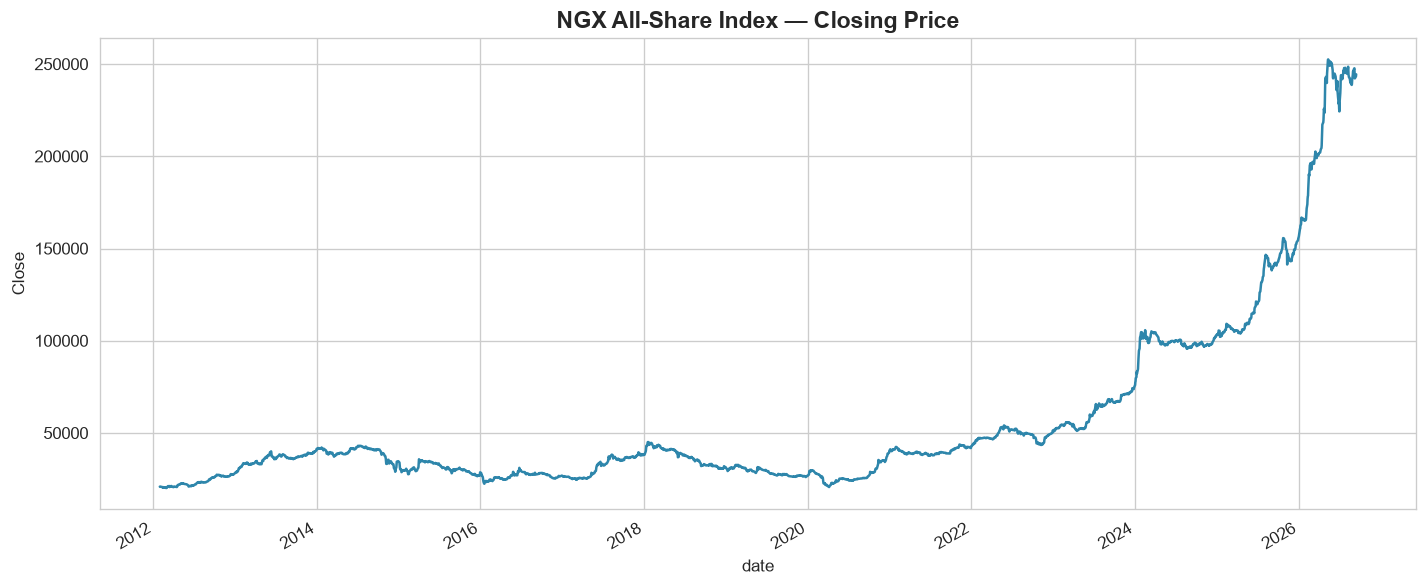

In [2]:
fig, ax = plt.subplots(figsize=(12, 5))
df["close"].plot(ax=ax, color="#2E86AB")
ax.set_title("NGX All-Share Index — Closing Price", fontsize=14, fontweight="bold")
ax.set_ylabel("Close")
plt.tight_layout()
plt.savefig("../visuals/price_trend.png", dpi=150)
plt.show()

## 2. Seasonal Decomposition

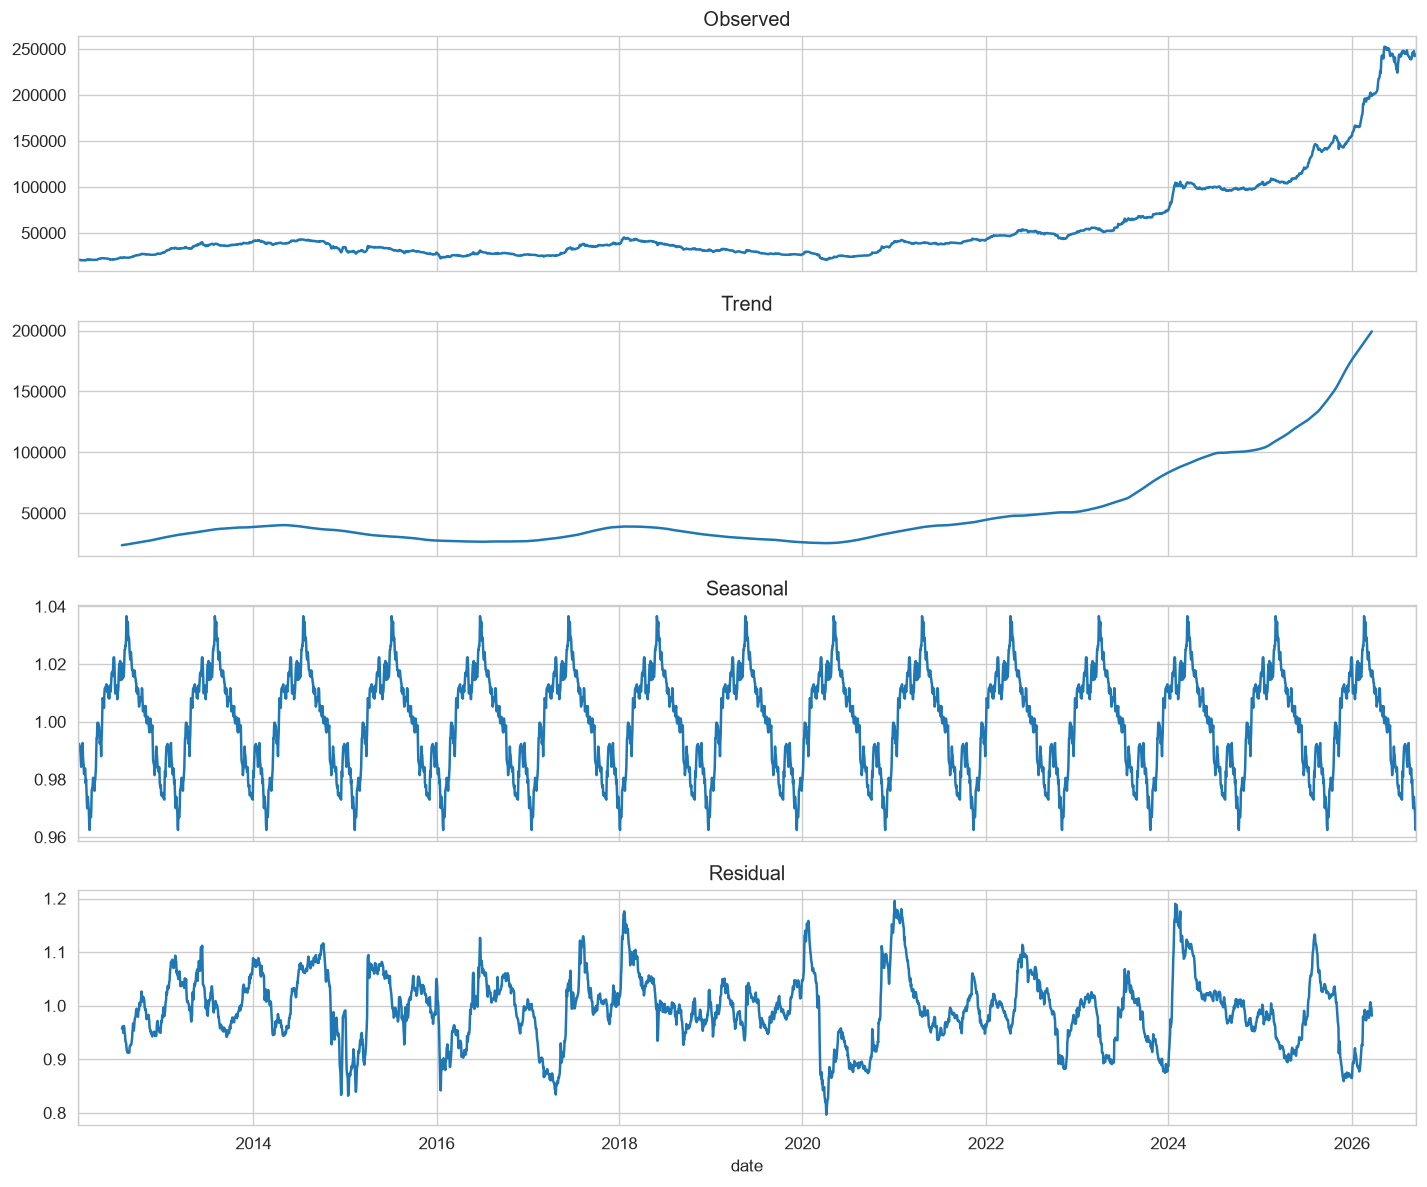

In [3]:
# Requires a regular frequency - resample to business-day frequency and forward-fill
# small gaps (holidays) for decomposition purposes only
df_resampled = df["close"].asfreq("B").ffill()

decomposition = seasonal_decompose(df_resampled, model="multiplicative", period=252)  # ~252 trading days/year

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
decomposition.observed.plot(ax=axes[0], title="Observed")
decomposition.trend.plot(ax=axes[1], title="Trend")
decomposition.seasonal.plot(ax=axes[2], title="Seasonal")
decomposition.resid.plot(ax=axes[3], title="Residual")
plt.tight_layout()
plt.show()

## 3. Rolling Volatility (Volatility Clustering)

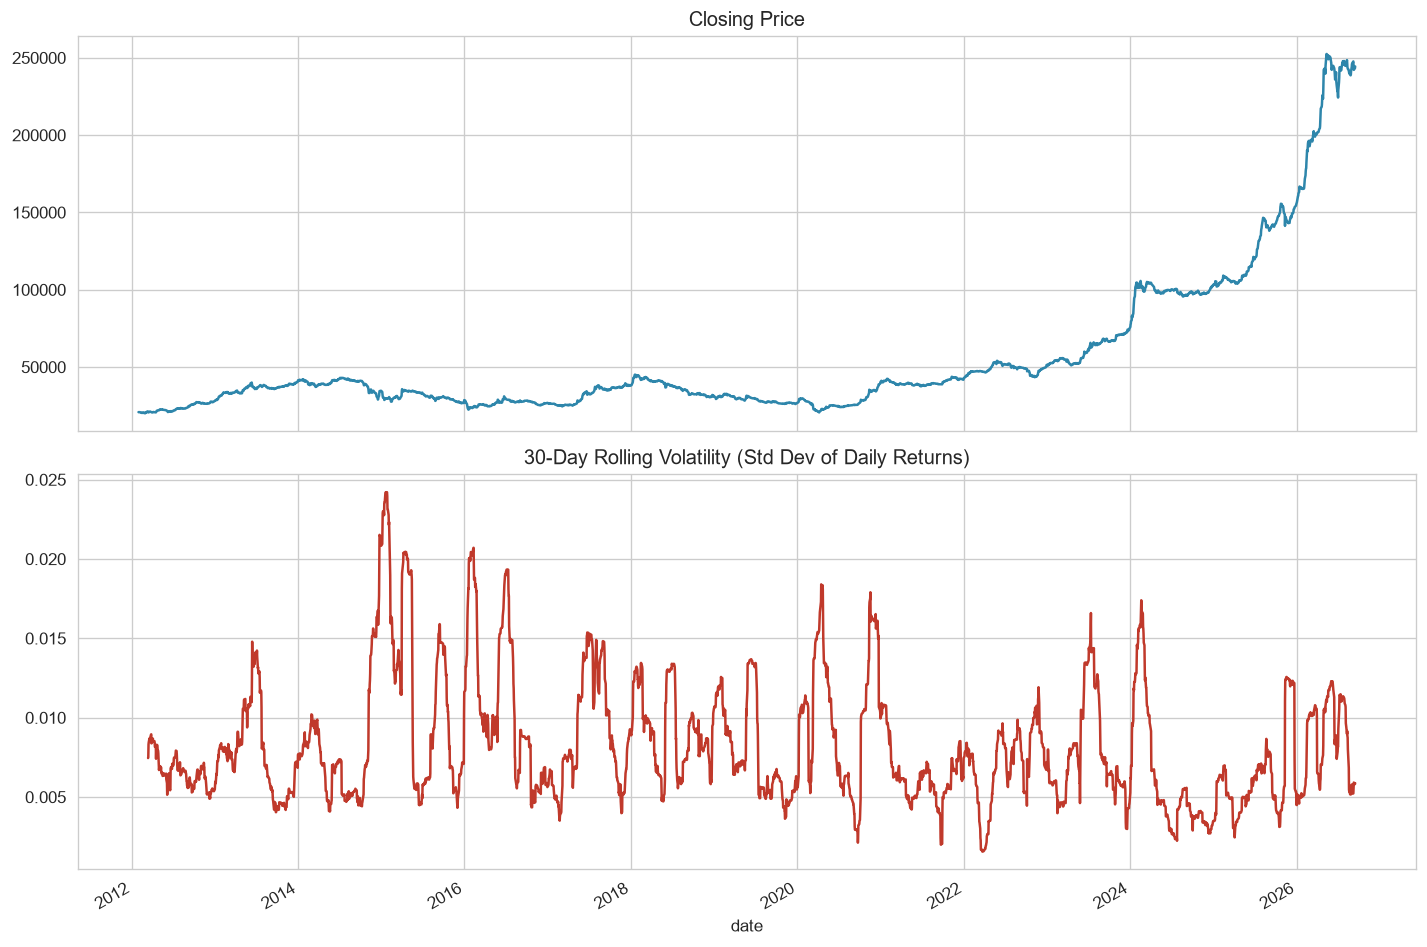

In [4]:
df["rolling_volatility_30d"] = df["daily_return"].rolling(window=30).std()

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
df["close"].plot(ax=axes[0], color="#2E86AB")
axes[0].set_title("Closing Price")

df["rolling_volatility_30d"].plot(ax=axes[1], color="#C0392B")
axes[1].set_title("30-Day Rolling Volatility (Std Dev of Daily Returns)")
plt.tight_layout()
plt.savefig("../visuals/rolling_volatility.png", dpi=150)
plt.show()

**Takeaway:** Volatility clusters visibly around three periods: **2015-2016** (the highest 
sustained volatility in the entire sample, with two distinct peaks reaching ~0.024), a 
smaller cluster around **2020** (coinciding with the global COVID-19 market shock), and a 
renewed spike in **2023-2024** — notably, this last cluster coincides exactly with the start 
of the index's dramatic price appreciation, where the close price roughly quintupled from 
~50,000 to ~250,000 in under three years. Interestingly, despite reaching all-time-high price 
levels through 2025-2026, volatility during this period has actually moderated back to levels 
similar to the earlier 2012-2019 range — suggesting the recent rally, while enormous in 
magnitude, has been comparatively orderly rather than chaotic. This is consistent with 
volatility clustering behavior: turbulent periods (2015-16, 2020, 2023-24) group together 
rather than appearing as isolated random spikes, and elevated volatility does not necessarily 
persist once a price trend stabilizes at a new level.

## 4. Stationarity Testing (Augmented Dickey-Fuller Test)

**Why this matters:** ARIMA assumes the series is stationary (constant mean/variance over
time). Raw stock prices are almost never stationary — they trend. The ADF test's null
hypothesis is "the series is non-stationary"; a p-value below 0.05 lets us reject that and
proceed.

In [5]:
def adf_test(series, label):
    result = adfuller(series.dropna())
    print(f"--- ADF Test: {label} ---")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    if result[1] < 0.05:
        print("=> Stationary (reject null hypothesis)")
    else:
        print("=> Non-stationary (fail to reject null hypothesis)")
    print()

adf_test(df["close"], "Raw Close Price")
adf_test(df["close"].diff(), "First-Differenced Close Price")
adf_test(df["daily_return"], "Daily Returns")

C:\Users\DREAMUSER\AppData\Local\Temp\ipykernel_14716\1395757745.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(series.dropna())


--- ADF Test: Raw Close Price ---
ADF Statistic: 4.3537
p-value: 1.0000
=> Non-stationary (fail to reject null hypothesis)



C:\Users\DREAMUSER\AppData\Local\Temp\ipykernel_14716\1395757745.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(series.dropna())


--- ADF Test: First-Differenced Close Price ---
ADF Statistic: -9.6216
p-value: 0.0000
=> Stationary (reject null hypothesis)

--- ADF Test: Daily Returns ---
ADF Statistic: -17.2308
p-value: 0.0000
=> Stationary (reject null hypothesis)



C:\Users\DREAMUSER\AppData\Local\Temp\ipykernel_14716\1395757745.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(series.dropna())


**Takeaway:** *(fill in once run)* — e.g. "The raw price series is non-stationary (p > 0.05), but first-differencing makes it stationary (p < 0.05), confirming ARIMA should be fit on the differenced series (i.e., an ARIMA model with d=1)."

## 5. Autocorrelation (ACF/PACF) — Informs ARIMA Parameter Choice

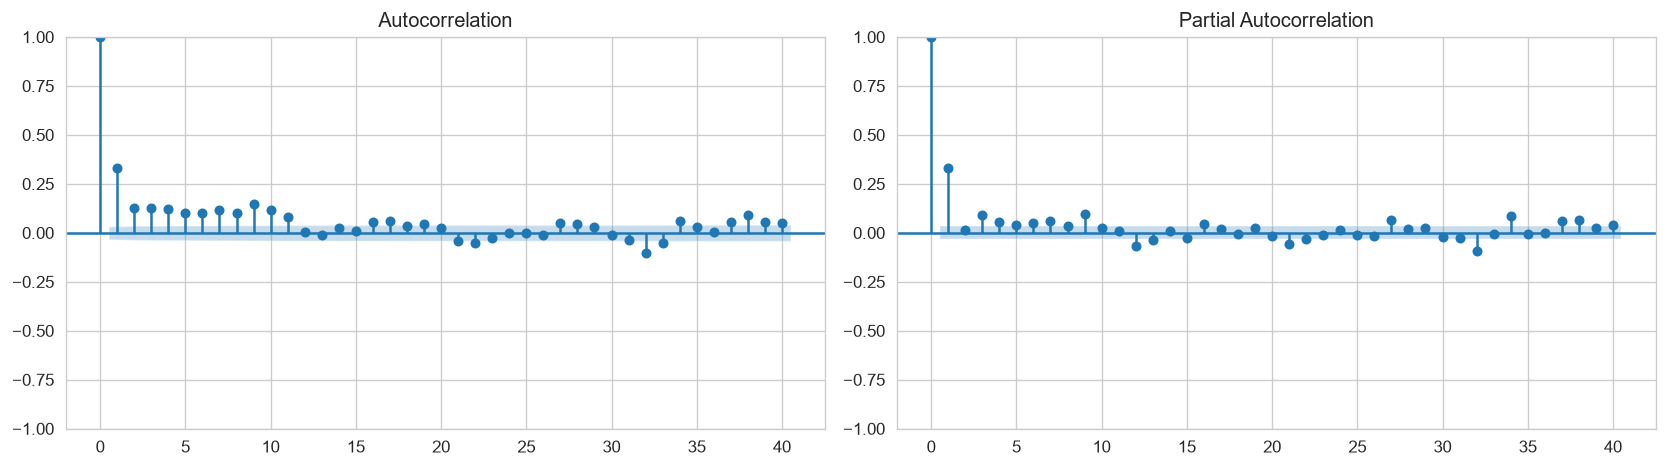

In [6]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(df["close"].diff().dropna(), ax=axes[0], lags=40)
plot_pacf(df["close"].diff().dropna(), ax=axes[1], lags=40)
plt.tight_layout()
plt.show()

The ACF/PACF plots above guide the choice of ARIMA's `p` (AR order) and `q` (MA order) parameters in notebook 03 — significant spikes indicate how many lag terms are worth including.